In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import sys
from glob import glob
import pypower
from pypower import idx_bus
from pypower import idx_gen
from pypower import idx_brch
from pypower import idx_cost
import pypsa
import geopandas as gpd
import us
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

## Set up matpower matrices

In [2]:
gen_idxs = [atr for atr in dir(idx_gen) if '__' not in atr]
gen_header_map = {getattr(idx_gen, atr):atr for atr in gen_idxs}

In [3]:
bus_idxs = [atr for atr in dir(idx_bus) if '__' not in atr]
bus_col_map = {atr:getattr(pypower.idx_bus, atr) for atr in bus_idxs}
del bus_col_map['NONE']
del bus_col_map['REF']
del bus_col_map['PQ']
del bus_col_map['PV']
bus_header_map = {v:k for k,v in bus_col_map.items()}

In [4]:
brch_idxs = [atr for atr in dir(idx_brch) if '__' not in atr]
brch_header_map = {getattr(idx_brch, atr):atr for atr in brch_idxs}

In [5]:
cost_idxs = [atr for atr in dir(idx_cost) if '__' not in atr]
print(len(cost_idxs))
cost_header_map = {getattr(idx_cost, atr):atr for atr in cost_idxs}
print(len(cost_header_map))
cost_header_map

7
5


{4: 'COST', 0: 'MODEL', 3: 'NCOST', 2: 'SHUTDOWN', 1: 'STARTUP'}

In [6]:
data_path = Path("../case_data/")
files = glob(str(data_path/"*"))
files

['..\\case_data\\Midwest24k_20220923.m',
 '..\\case_data\\Midwest24k_BusMetaData.csv',
 '..\\case_data\\Midwest24k_SubstationMetaData.csv',
 '..\\case_data\\timeseries',
 '..\\case_data\\Wisconsin_1664.m',
 '..\\case_data\\Wisconsin_1664.PWB',
 '..\\case_data\\Wisconsin_1664_BusMetaData.csv']

In [8]:
case_path = Path(files[4])
case_path

WindowsPath('../case_data/Wisconsin_1664.m')

In [46]:
with open(case_path, "r") as file:
    data = file.readlines()
    
pypsa_comps = {}

print(len(data))
metadata = {}
start_row = []
for i, line in enumerate(data):
    if ("%%" in line):
        print(i)
        obj_name = line.replace("data", "").replace('%%','').strip()
        print(obj_name)
        metadata[obj_name] = i
        start_row.append(i)

start_row.append(len(data))

6138
5
bus
1673
generator
1756
generator cost
1839
branch
4305
bus names
5973
Generator Unit Types
6056
Generator Fuel Types


In [47]:
components = {}
for n, (name, row) in enumerate(metadata.items()):
    print(n, name, row)
    print(f"Streaming {start_row[n+1]-row-4} rows")
    comp = pd.read_csv(case_path, sep=r'\s+', skiprows=row+2, nrows=start_row[n+1]-row-4, header=None)
    components[name] = comp

components['generator'].rename(columns=gen_header_map, inplace=True)
components['generator cost'].rename(columns=cost_header_map, inplace=True)
components['bus'].rename(columns=bus_header_map, inplace=True)
components['branch'].rename(columns=brch_header_map, inplace=True)

0 bus 5
Streaming 1664 rows
1 generator 1673
Streaming 79 rows
2 generator cost 1756
Streaming 79 rows
3 branch 1839
Streaming 2462 rows
4 bus names 4305
Streaming 1664 rows
5 Generator Unit Types 5973
Streaming 79 rows
6 Generator Fuel Types 6056
Streaming 78 rows


In [48]:
# clean up the strings
components['Generator Fuel Types'] = components['Generator Fuel Types'].loc[:,0].str.replace('\'','').str.replace(';','')
components['Generator Unit Types'] = components['Generator Unit Types'][0].str.replace("\'","").str.replace(';','')
components['bus names'] = components['bus names'][0].str.replace("\'","").str.replace(';','')

# add name to buses
components['bus'] = components['bus'].assign(NAME=components['bus names'].values)

# map cost onto generator
components['generator cost'] = components['generator cost'].assign(GEN_BUS=components['generator']['GEN_BUS'].values)
# remove duplicate row
components['generator cost'] = components['generator cost'].loc[~components['generator cost'].duplicated()].reset_index(drop=True)

# Add unit type to generator matrix
components['generator'] = components['generator'].assign(unit_type=components['Generator Unit Types'].values)

# add generator fuel type
fuels = list(components['Generator Fuel Types'].values)
fuels.append('wind')
components['generator'] = components['generator'].assign(carrier=fuels)
# remove duplicate row
components['generator'] = components['generator'].loc[~components['generator'].duplicated()].reset_index(drop=True)
display(components['generator'])


,GEN_BUS,PG,QG,QMAX,QMIN,VG,MBASE,GEN_STATUS,PMAX,PMIN,...,QC1MAX,QC2MIN,QC2MAX,RAMP_AGC,RAMP_10,RAMP_30,RAMP_Q,APF,unit_type,carrier
0,1,1214.97,-27.89,466.80,-422.70,1.02,100.0,1,1286.0,300.0,...,0.0,0.0,0.0,0,0,0,0,0.0,NP,nuclear
1,2,892.20,179.91,683.20,-407.60,1.02,100.0,1,1240.0,480.0,...,0.0,0.0,0.0,0,0,0,0,0.0,ST,coal
2,3,657.50,209.37,764.30,-405.30,1.02,100.0,1,1233.2,600.0,...,0.0,0.0,0.0,0,0,0,0,0.0,ST,coal
3,4,280.00,52.57,374.55,-198.65,1.02,100.0,1,604.4,280.0,...,0.0,0.0,0.0,0,0,0,0,0.0,CC,ng
4,5,895.80,-76.37,538.60,-365.50,1.02,100.0,1,1112.0,300.0,...,0.0,0.0,0.0,0,0,0,0,0.0,ST,coal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,74,5.40,13.57,16.20,-7.10,1.02,100.0,1,21.6,5.4,...,0.0,0.0,0.0,0,0,0,0,0.0,HY,hydro
74,75,20.80,7.84,15.60,-6.80,1.02,100.0,1,20.8,20.8,...,0.0,0.0,0.0,0,0,0,0,0.0,ST,wood
75,76,3.40,15.00,15.00,-6.60,1.02,100.0,1,20.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0.0,HY,hydro
76,77,4.00,-6.60,15.00,-6.60,1.02,100.0,1,20.0,4.0,...,0.0,0.0,0.0,0,0,0,0,0.0,ST,wood


In [49]:
components['generator'].columns

Index(['GEN_BUS', 'PG', 'QG', 'QMAX', 'QMIN', 'VG', 'MBASE', 'GEN_STATUS',
       'PMAX', 'PMIN', 'PC1', 'PC2', 'QC1MIN', 'QC1MAX', 'QC2MIN', 'QC2MAX',
       'RAMP_AGC', 'RAMP_10', 'RAMP_30', 'RAMP_Q', 'APF', 'unit_type',
       'carrier'],
      dtype='str')

## Bus Location Data

### Get Wisconsin Shape File

In [12]:
from zipfile import ZipFile
import requests
import json
import io

state = 'wisconsin'
fips = us.states.lookup(state).fips
year = 2025
fname = f"tl_{year}_{fips}_tract"
tract_url = f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/{fname}.zip"
county_url = 'https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_5m.zip'

In [ ]:
# download shapefile from URL
r = requests.get(tract_url)
print(r.status_code)
zf = ZipFile(io.BytesIO(r.content))
zf.extractall()

In [13]:
# gdf = gpd.read_file('cb_2018_us_county_5m.shp')
gdf = gpd.read_file(f'{fname}.shp')
gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,55,019,950800,55019950800,1400000US55019950800,9508,Census Tract 9508,G5020,S,794216668,8168460,+44.5759654,-090.7481080,"POLYGON ((-90.92288 44.50992, -90.92286 44.510..."
1,55,019,950500,55019950500,1400000US55019950500,9505,Census Tract 9505,G5020,S,411510103,886442,+44.7920881,-090.4318739,"POLYGON ((-90.55764 44.85698, -90.55763 44.859..."
2,55,019,950100,55019950100,1400000US55019950100,9501,Census Tract 9501,G5020,S,105161812,384034,+44.9773747,-090.3669679,"POLYGON ((-90.43417 44.96585, -90.43415 44.966..."
3,55,019,950700,55019950700,1400000US55019950700,9507,Census Tract 9507,G5020,S,104152998,1410731,+44.6211439,-090.6045574,"POLYGON ((-90.65958 44.64192, -90.65957 44.642..."
4,55,019,950400,55019950400,1400000US55019950400,9504,Census Tract 9504,G5020,S,564233017,5519077,+44.8087893,-090.7306337,"POLYGON ((-90.92251 44.90083, -90.92032 44.900..."


In [14]:
bus_meta = pd.read_csv(data_path/'Wisconsin_1664_BusMetaData.csv', skiprows=1)
bus_gdf = gpd.GeoDataFrame(bus_meta, geometry=gpd.points_from_xy(bus_meta.Longitude,bus_meta.Latitude), crs='EPSG:4269')

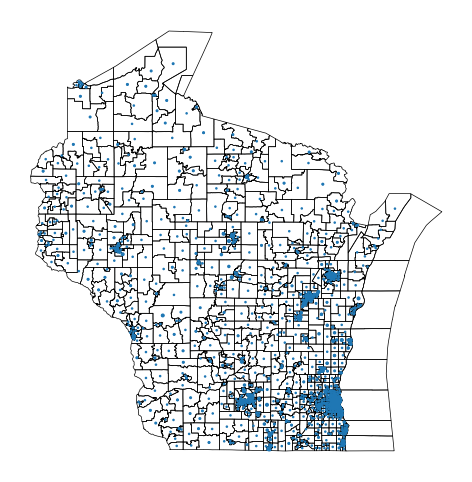

In [15]:
fig, ax = plt.subplots(figsize=(8,6))
gdf.plot(ax=ax, ec='k', lw=0.5, fc='None')
bus_gdf.plot(ax=ax, markersize=bus_gdf['Nom kV']/1e2)
ax.set_axis_off()

## Set up PyPSA network

In [16]:
bus_gdf.columns

Index(['Number', 'Name', 'Labels All', 'Area Name', 'Zone Name', 'Nom kV',
       'Latitude', 'Longitude', 'geometry'],
      dtype='str')

In [89]:
n = pypsa.Network(name='Wisconsin')

In [90]:
# add buses
for _,row in tqdm(bus_gdf.iterrows()):
    n.add("Bus", 
          name=row.Number, 
          carrier='AC', 
          x=row.Longitude, 
          y=row.Latitude,
          v_nom=row['Nom kV'],
          location=row.Name
          )

0it [00:00, ?it/s]

In [91]:
carrier_colors = dict(zip(components['generator'].carrier.unique(), 
                          ['magenta',
                           'tab:brown',
                           'tab:orange',
                           'black',
                           'tab:cyan',
                           'tab:green',
                           'tab:blue'
                           ]))

colors = ['magenta',
        'tab:brown',
        'tab:orange',
        'black',
        'tab:cyan',
        'tab:green',
        'tab:blue'
        ]                        

In [92]:
# add carriers
n.add("Carrier", 
      name = components['generator'].carrier.unique(),
      color = colors
      )

In [93]:
gen_costs = components['generator cost']

In [94]:
for i, row in tqdm(components['generator'].iterrows()):
    n.add(
        "Generator",
        name = f"Bus {row.GEN_BUS} {row.carrier}",
        bus = row.GEN_BUS,
        carrier = row.carrier,
        type=row.unit_type,
        p_nom=row.PMAX,
        p_nom_extendable=False,
        p_max_pu=1.0,
        p_min_pu=row.PMIN/row.PMAX,
        marginal_cost=gen_costs.loc[i, 6],
        marginal_cost_quadratic=gen_costs.loc[i, 5],
        stand_by_cost=gen_costs.loc[i,7],
        committable=(row.PMIN>0)
    )

0it [00:00, ?it/s]

In [95]:
branches = components['branch']
branches['NUMBER'] = components['branch'].groupby(['F_BUS','T_BUS']).cumcount()+1

In [96]:
for i, row in tqdm(components['branch'].iterrows()):
    comp_type = "Transformer" if (row.TAP > 0) else "Line"
    n.add(
        comp_type,
        name=f"{int(row.F_BUS)}_{int(row.T_BUS)}_{int(row.NUMBER)}",
        bus0=int(row.F_BUS),
        bus1=int(row.T_BUS),
        x=row.BR_X,
        r=row.BR_R,
        v_ang_min=row.ANGMIN,
    )

0it [00:00, ?it/s]

In [101]:
n

PyPSA Network 'Wisconsin'
-------------------------
Components:
 - Bus: 1664
 - Carrier: 7
 - Generator: 78
 - Line: 1902
 - Load: 1393
 - Transformer: 560
Snapshots: 1

In [100]:
for i, row in tqdm(components['bus'].iterrows()):
    if row.PD > 0:
        n.add(
            "Load",
            name=f'Bus {row.BUS_I} Load',
            bus=int(row.BUS_I),
            carrier='AC',
            p_set=row.PD,
            q_set=row.QD,
        )

0it [00:00, ?it/s]

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x298d643ec10>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x298d3dfcc20>,
  'Transformer': <matplotlib.collections.LineCollection at 0x298d643ed50>},
 'flows': {}}

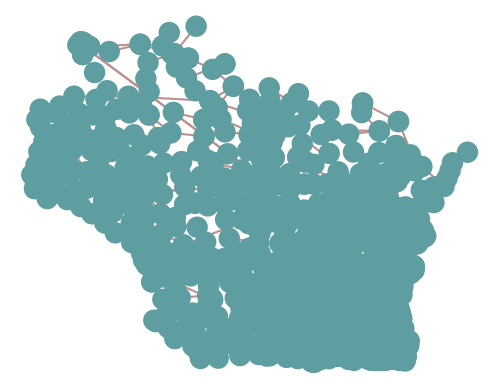

In [102]:
n.plot()